# 1. Carregando um Dataset

[EEGDash](https://eegdash.org/) é uma biblioteca Pythoncom 700+ datasets de EEG Open-Source. [EEGDash-Paper](https://arxiv.org/abs/2606.16041)

## 1.1 Setup

Para encontrar datasets, podemos verificar o [Catálogo](https://eegdash.org/dataset_summary.html). Vamos utilizar o Dataset [DS002721 - EEG data investigating neural correlates of music-induced emotion](https://eegdash.org/api/dataset/eegdash.dataset.DS002721.html).

Descrição do Dataset: The purpose of the research activity in which the data were collected was to investigate the EEG neural correlates of music-induced emotion. For this purpose 31 healthy adult participants listened to 40 music clips of 12 s duration each, targeting a range of emotional states. The music clips comprised excerpts from film scores spanning a range of styles and rated on induced emotion. The dataset contains **unprocessed EEG data** from all 31 participants (age range 18-66, 18 female) while listening to the music clips, together with the reported induced emotional responses . **The paradigm involved 6 runs of EEG recordings**. **The first and last runs were resting state runs, during which participants were instructed to sit still and rest for 300 s**. **The other 4 runs each contained 10 music listening trials**.

In [2]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd

import eegdash
from eegdash import EEGDashDataset
from eegdash.viz import style_figure, use_eegdash_style

# Force MNE's matplotlib browser so raw.plot returns a Figure (the Qt
# browser returns an MNEQtBrowser instance and skips static capture).
mne.viz.set_browser_backend("matplotlib")

use_eegdash_style() # Configura matplotlib/seaborn para plots EEG
cache_dir = os.environ.get("EEGDASH_CACHE_DIR", str(Path.home() / ".eegdash_cache")) # /home/user/.eegdash_caache -> Onde são baixados os datasets
print(f"eegdash {eegdash.__version__}; cache_dir={cache_dir}")

/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:497: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/braindecode/models/eegpt.py:1452: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = make_standard_montage("standard_1

Using matplotlib as 2D backend.
eegdash 0.9.1; cache_dir=/home/arielalves/.eegdash_cache


## 1.2 Conceitos por trás do EEGDashDataset

- **Metadata index vs. file blobs** - O EEGDash separa *records* (pequenos arquivos JSON) de *files* (BIDS payloads no OpenNeuro / S3). Uma query busca apenas os metadados, os bytes brutos esperam.

- **Lazy by default** - `EEGDashDataset` retorna imediatamente, sem baixar nada da rede. Cada entrada de registro possui a propriedade `raw`, e o download (apenas para aquele registro) ocorre na primeira vez que essa propriedade é lida.

- **Herança do Braindecode** - `EEGDashDataset` é um `braindecode.datasets.BaseConcatDataset`. Qualquer código que aceita esse tipo (como `create_fixed_length_windows(ds, ...)`, `DataLoader(ds, ...)`, `Preprocessor(...)`) aceita um `EEGDashDataset` de igual modo.


*BIDS - Brain Imaging Data Structure. Padrão internacional para ogranizar e compartilhar dados de exames fMRI, EEG e MEG.

## Conceitos por trás do EEGDashDataset

- **Metadata index vs. file blobs** - O EEGDash separa *records* (pequenos arquivos JSON) de *files* (BIDS payloads no OpenNeuro / S3). Uma query busca apenas os metadados, os bytes brutos esperam.

- **Lazy by default** - `EEGDashDataset` retorna imediatamente, sem baixar nada da rede. Cada entrada de registro possui a propriedade `raw`, e o download (apenas para aquele registro) ocorre na primeira vez que essa propriedade é lida.

- **Herança do Braindecode** - `EEGDashDataset` é um `braindecode.datasets.BaseConcatDataset`. Qualquer código que aceita esse tipo (como `create_fixed_length_windows(ds, ...)`, `DataLoader(ds, ...)`, `Preprocessor(...)`) aceita um `EEGDashDataset` de igual modo.


*BIDS - Brain Imaging Data Structure. Padrão internacional para ogranizar e compartilhar dados de exames fMRI, EEG e MEG.

## 1.3 Buscando o Dataset

Ao buscar o dataset, serão baixados os metadados apenas.

In [3]:
from eegdash.dataset import DS002721

DATASET = "ds002721"
SUBJECT = "001"

# Seleciona todos
#dataset = DS002721(cache_dir="./data") # Seleciona todos

# Seleciona 1

dataset = DS002721(cache_dir="./data", subject="01") 

# Seleciona vários

# dataset = DS002721(
#     cache_dir="./data",
#     query={"subject": {"$in": ["01", "02"]}},
# )

dataset

[09/13/26 12:43:12] WARNING  MNE-BIDS failed due to missing file (File does not exist:                 ]8;id=11365299;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/base.py\base.py]8;;\:]8;id=11365300;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/base.py#1848\1848]8;;\
                             data/ds002721/sub-01/eeg/sub-01_task-_eeg.edf                                         
                             Did you mean one of:                                                                  
                             sub-01_task-run3_eeg.edf                                                              
                             sub-01_task-run3_eeg.json                                                             
                             sub-01_task-run3_events.tsv                                                           
                             instead of:                                                                           
                             sub-01_task-_eeg.edf), falling back to direct MNE reader.                             

                    WARNING  Falling back to direct .edf reader for sub-01_task-run3_eeg.edf (bypassing  ]8;id=11365307;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/io.py\io.py]8;;\:]8;id=11365308;file:///home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/dataset/io.py#1652\1652]8;;\
                             MNE-BIDS).                                                                            

<BaseConcatDataset | 6 EEGDashRaw(s) | 2791000 total samples>
  Sfreq*: 1000.0 Hz
  Channels*: 19 (19 EEG)
  Ch. names*: FP1, FP2, F7, F3, Fz, F4, F8, T3, C3, Cz, ... (+9 more)
  Duration*: 552.0 s
  (* from first recording)
  Description: 6 recordings × 7 columns [subject, task, age, sex, session, run, gender]

## 1.4 Pegando uma gravação

A classe `EEGDashDataset` possui uma lista `EEGDashDataset.datasets` com as entradas de registro, onde cada entrada é uma classe `EEGDashBaseDataset` carregando um caminho BIDS, uma descrição e uma propriedade `raw` lazy (em espera). 

`record.raw` ativa o download, e devolve um objeto `mne`*.

*Ferramenta para processamento de sinais EEG e MEG.

In [4]:
record = dataset.datasets[0]
raw = record.raw

raw

<RawEDF | sub-01_task-run3_eeg.edf, 19 x 552000 (552.0 s), ~19 KiB, data not loaded>

## 1.5 Plotando o sinal

Rode `raw.plot` para renderizar uma janela de 8s em uma pequena seleção de canais.

For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


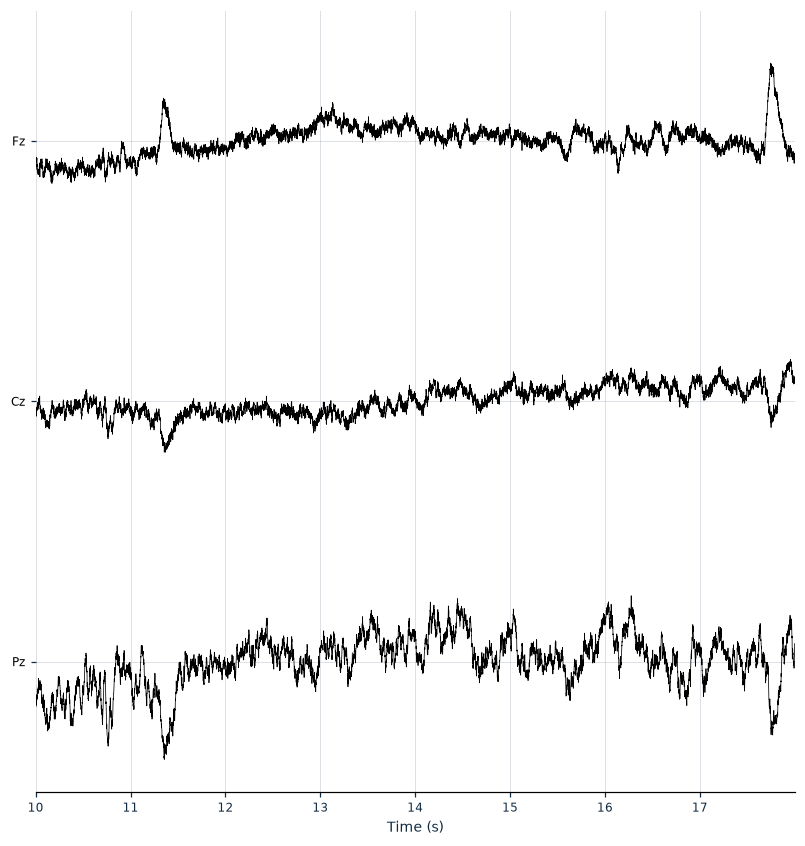

In [5]:
midline_picks = [
    ch
    for ch in ("Fz", "Cz", "Pz", "Oz", "FCz", "CPz", "POz", "T7", "T8")
    if ch in raw.ch_names
][:8]

fig_raw = raw.plot(
    start=10.0, #Início (s)
    duration=8.0, #Duração (s)
    picks=midline_picks if midline_picks else None, #Canais
    n_channels=8, #Número de canais
    scalings={"eeg": 50e-6}, #Escala
    show=True,
    show_scrollbars=False,
    show_scalebars=False,
    title="",
)

## 1.6 Topologia dos sensores

A posição dos eletrodos importa para análise posterior. `raw.plot_sensors` desenha um esquemático de uma cabeça 2D, com 74 canais possíveis.

O dataset ds002721 usa o layout 10-20 padrão (Fp1, Fp2, F3, F4, ... Cz, Pz, 19 eletrodos). `standard_1020` cobre todos eles.

/tmp/ipykernel_130792/2142656934.py:1: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  raw.set_montage(


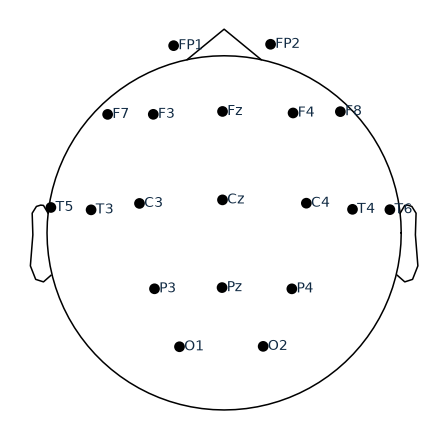

In [6]:
raw.set_montage(
    "standard_1020", #Padrão internacional
    match_case=False,
    match_alias=True,
    on_missing="ignore", #Se canal não existir, ignora
)
has_positions = any(not np.allclose(ch["loc"][:3], 0.0) for ch in raw.info["chs"])
fig_sens, ax_sens = plt.subplots(figsize=(5.0, 5.0))
if has_positions:
    raw.plot_sensors(
        kind="topomap",
        show_names=True,
        axes=ax_sens,
        show=True,
    )
    ax_sens.set_title("")
else:
    ax_sens.text(
        0.5,
        0.5,
        "Sensor positions unavailable in this build's montage",
        ha="center",
        va="center",
    )
    ax_sens.set_axis_off()
fig_sens.tight_layout()

## 1.7 Densidade espectral de energia

Um PSD é uma boa primeira impressão da qualidade do sinal: ruídos de linha em 50/60 Hz, slow drifts abaixo de 1 Hz, broadband 1/f. Computamos Welch's PSD nos canais EEG e plotamos em dB.

Plotting power spectral density (dB=True).


/home/arielalves/Desktop/Iniciacao-cientifica-EEG-FM/EEGDash-Tutorials/Translated-Tutorials/.venv/lib/python3.12/site-packages/eegdash/viz/identity.py:178: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.84, bottom=0.18, left=0.12, right=0.95)


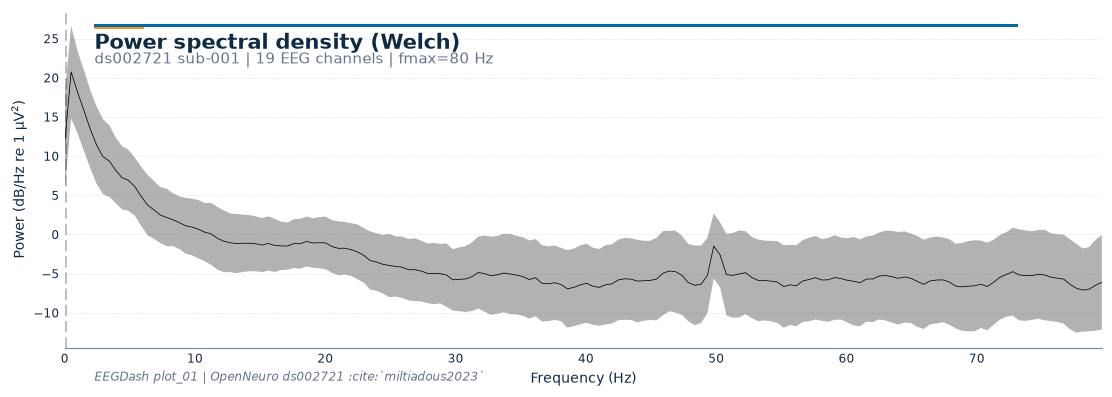

In [7]:
psd = raw.copy().pick("eeg").compute_psd(fmax=80.0, verbose=False)
fig_psd = psd.plot(picks="eeg", average=True, show=False)
style_figure(
    fig_psd,
    title="Power spectral density (Welch)",
    subtitle=f"{DATASET} sub-{SUBJECT} | {len(raw.copy().pick('eeg').ch_names)} EEG channels | fmax=80 Hz",
    source=f"EEGDash plot_01 | OpenNeuro {DATASET} :cite:`miltiadous2023`",
)
plt.show()

A Densidade Espectral de Potência (PSD - Power Spectral Density) mede a quantidade de energia (potência) presente em cada faixa de frequência de um sinal. No EEG, ela quantifica a força dos ritmos cerebrais (Delta, Theta, Alfa, Beta, Gama).

O Método de Welch é a abordagem padrão para estimar a PSD porque resolve um problema clássico: aplicar uma Transformada de Fourier (FFT) diretamente no sinal inteiro gera um espectro muito ruidoso e instável.

Como o Método de Welch Funciona (Passo a Passo)

1. Divisão em segmentos: O sinal contínuo é fatiado em blocos menores com sobreposição (tipicamente 50% de overlap).
2. Janelamento (Windowing): Aplica-se uma função de suavização (geralmente Janela de Hanning ou Hamming) em cada segmento para atenuar as bordas e evitar o vazamento espectral (spectral leakage).
3. Cálculo da FFT: A FFT é calculada individualmente para cada um dos segmentos janelados.
4. Média: Calcula-se a média do espectro de todos os segmentos.

A grande vantagem é que essa média reduz drasticamente a variância do ruído aleatório, gerando curvas de potência suaves e confiáveis, à custa de uma pequena perda de resolução de frequência.